In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

In [2]:
df=pd.read_excel(r"C:\Users\nihar\Downloads\Toy-Sales.xlsx")
df

,Month,Unit Sales,Price ($),Adexp ('000$),Promexp ('000$)
0,1,73959,8.75,50.04,61.13
1,2,71544,8.99,50.74,60.19
2,3,78587,7.50,50.14,59.16
3,4,80364,7.25,50.27,60.38
4,5,78771,7.40,51.25,59.71
5,6,71986,8.50,50.65,59.88
6,7,74885,8.40,50.87,60.14
7,8,73345,7.90,50.15,60.08
8,9,76659,7.25,48.24,59.90
9,10,71880,8.70,50.19,59.68


                            OLS Regression Results                            
Dep. Variable:             Unit Sales   R-squared:                       0.619
Model:                            OLS   Adj. R-squared:                  0.602
Method:                 Least Squares   F-statistic:                     35.74
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           5.13e-06
Time:                        10:05:15   Log-Likelihood:                -215.40
No. Observations:                  24   AIC:                             434.8
Df Residuals:                      22   BIC:                             437.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.142e+05   6695.944     17.057      0.0

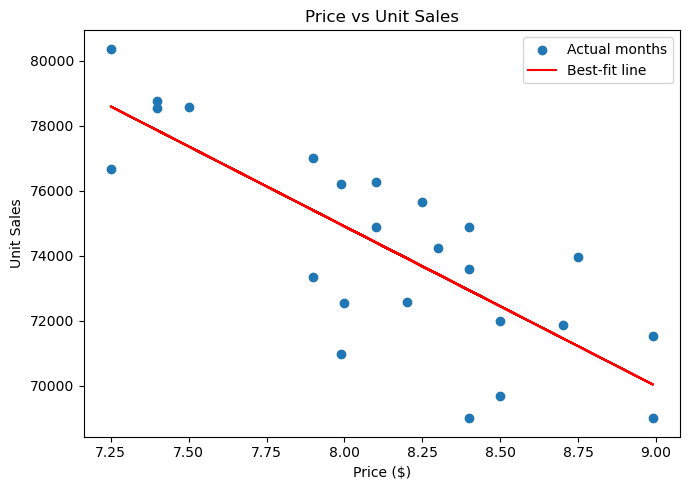

In [3]:
# 1. Define target (y) and predictor (X)
y = df["Unit Sales"]
X = df[["Price ($)"]]

# 2. Add constant for intercept and fit model
X_const = sm.add_constant(X)
model_simple = sm.OLS(y, X_const).fit()

# 3. Print summary
print(model_simple.summary())

# 4. Print equation and R-squared
b0 = model_simple.params["const"]
b1 = model_simple.params["Price ($)"]
print(f"\nEquation: Unit Sales = {b0:,.0f} + ({b1:,.0f} x Price)")
print(f"R-squared: {model_simple.rsquared:.2f}")

# 5. Plot scatter and best-fit line
plt.figure(figsize=(7, 5))
plt.scatter(df["Price ($)"], y, label="Actual months")
plt.plot(df["Price ($)"], model_simple.fittedvalues, "r-", label="Best-fit line")
plt.xlabel("Price ($)")
plt.ylabel("Unit Sales")
plt.title("Price vs Unit Sales")
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
predictors = ["Price ($)", "Adexp ('000$)", "Promexp ('000$)"]

# 1. Define target (y) and predictors (X)
y = df["Unit Sales"]
X_full = sm.add_constant(df[predictors])

# 2. Fit full regression model
model_full = sm.OLS(y, X_full).fit()

# 3. Print full regression summary
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:             Unit Sales   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                     40.56
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           1.08e-08
Time:                        10:05:22   Log-Likelihood:                -203.48
No. Observations:                  24   AIC:                             415.0
Df Residuals:                      20   BIC:                             419.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            -2.51e+04   2.49e+04     

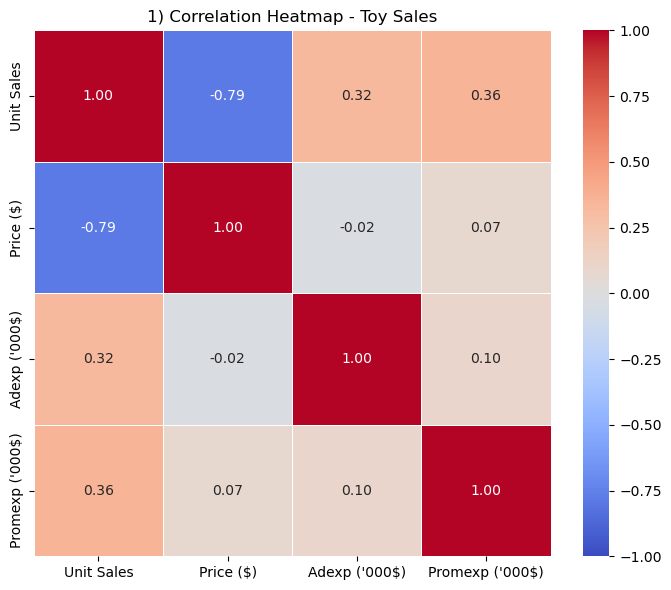

In [5]:
cols = ["Unit Sales"] + predictors
corr = df[cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(
    corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", linewidths=0.5
)
plt.title("1) Correlation Heatmap - Toy Sales")
plt.tight_layout()
plt.show()

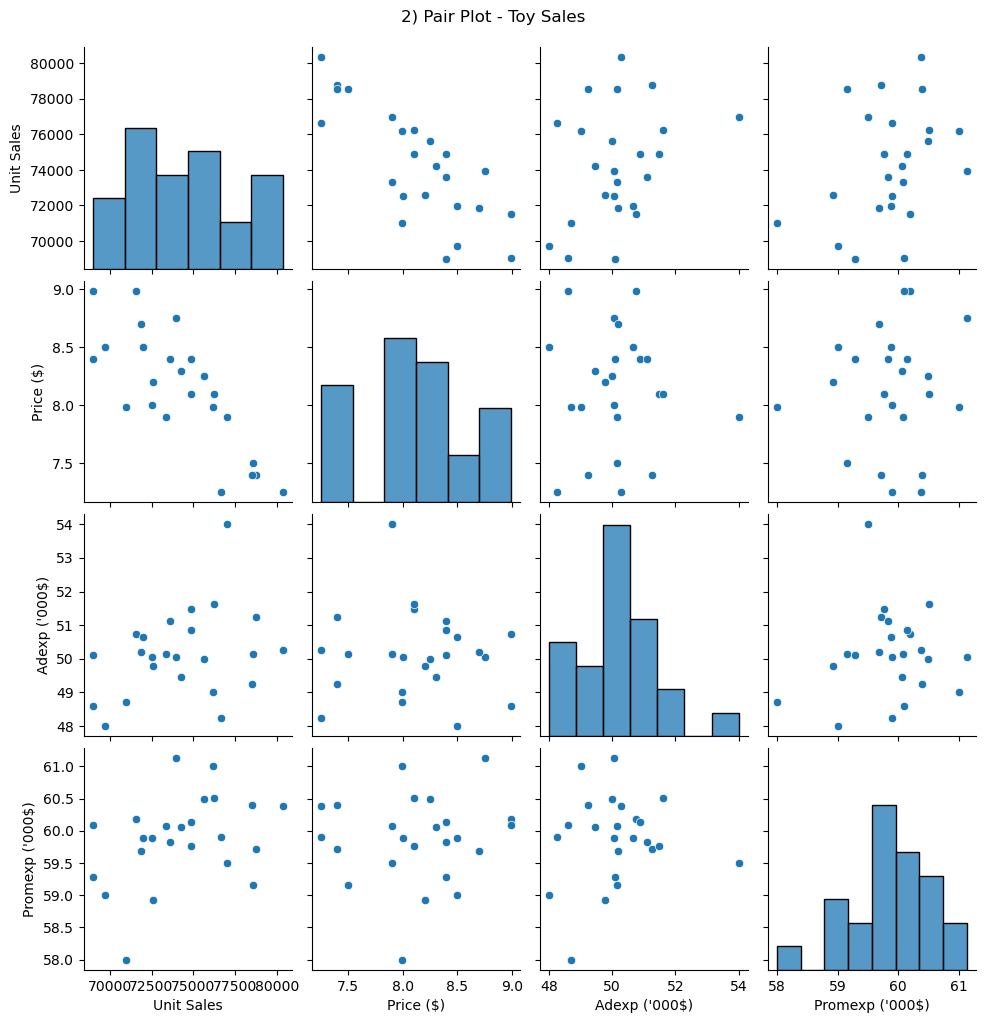

In [6]:
pair = sns.pairplot(df[cols], kind="scatter", diag_kind="hist")
pair.fig.suptitle("2) Pair Plot - Toy Sales", y=1.02)
plt.show()

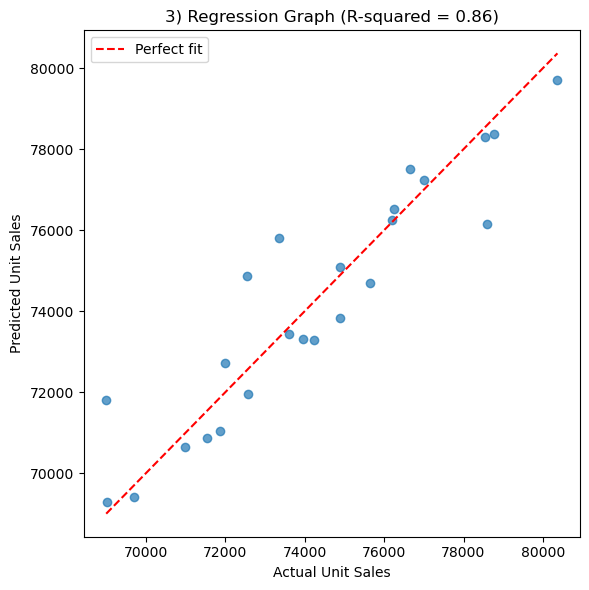

In [7]:
predicted = model_full.fittedvalues

plt.figure(figsize=(6, 6))
plt.scatter(y, predicted, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", label="Perfect fit")
plt.xlabel("Actual Unit Sales")
plt.ylabel("Predicted Unit Sales")
plt.title(f"3) Regression Graph (R-squared = {model_full.rsquared:.2f})")
plt.legend()
plt.tight_layout()
plt.show()

INDIVIDUAL (SINGLE-FACTOR) REGRESSIONS

Unit Sales vs Price ($)
  Equation : Unit Sales = 114,215 + (-4,913.7 x Price ($))
  Slope    : -4,913.7
  R-squared: 0.619
  P-value  : 0.0000 -> SIGNIFICANT

Unit Sales vs Adexp ('000$)
  Equation : Unit Sales = 34,487 + (793.0 x Adexp ('000$))
  Slope    : 793.0
  R-squared: 0.103
  P-value  : 0.1267 -> not significant

Unit Sales vs Promexp ('000$)
  Equation : Unit Sales = -24,349 + (1,646.9 x Promexp ('000$))
  Slope    : 1,646.9
  R-squared: 0.126
  P-value  : 0.0887 -> not significant


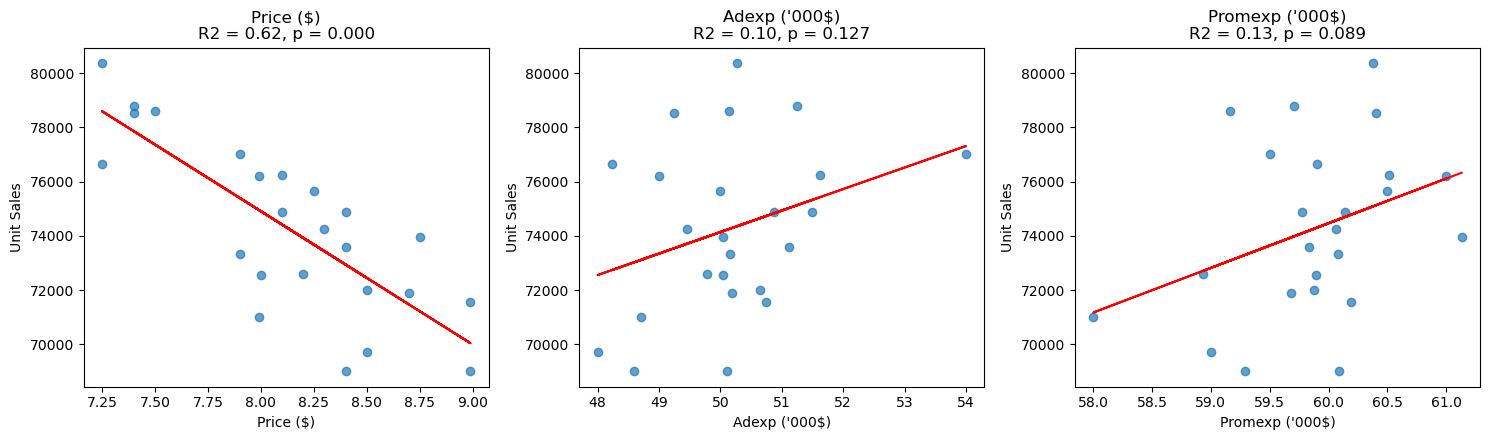

In [8]:
print("=" * 60)
print("INDIVIDUAL (SINGLE-FACTOR) REGRESSIONS")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, col in zip(axes, predictors):
    Xi = sm.add_constant(df[col])
    m1 = sm.OLS(y, Xi).fit()

    slope = m1.params[col]
    r2 = m1.rsquared
    p = m1.pvalues[col]
    sig = "SIGNIFICANT" if p < 0.05 else "not significant"

    print(f"\nUnit Sales vs {col}")
    print(f"  Equation : Unit Sales = {m1.params['const']:,.0f} + ({slope:,.1f} x {col})")
    print(f"  Slope    : {slope:,.1f}")
    print(f"  R-squared: {r2:.3f}")
    print(f"  P-value  : {p:.4f} -> {sig}")

    ax.scatter(df[col], y, alpha=0.7)
    ax.plot(df[col], m1.fittedvalues, "r-")
    ax.set_xlabel(col)
    ax.set_ylabel("Unit Sales")
    ax.set_title(f"{col}\nR2 = {r2:.2f}, p = {p:.3f}")

plt.tight_layout()
plt.show()